# Verifica su Pandas e Matplotlib
**NOTA**:  ⚠️ istruzioni e costrutti python/numpy non visti a lezione invalideranno la soluzione degli esercizi! ⚠️

Per ogni grafico includi titoli e etichette appropriati.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Scarica il dataset sul rendimento scolastico `Expanded_data_with_more_features.csv` e rispondi alle domande seguenti.

**Descrizione delle colonne**

1. **Gender**: Genere dello studente (maschio/femmina)
2. **EthnicGroup**: Gruppo etnico dello studente (gruppi da A a E)
3. **ParentEduc**: Livello di istruzione dei genitori (da diploma parziale a laurea magistrale)
4. **LunchType**: Tipo di pranzo scolastico (standard o gratuito/ridotto)
5. **TestPrep**: Corso di preparazione al test seguito (completato o nessuno)
6. **ParentMaritalStatus**: Stato civile dei genitori (sposati/single/vedovi/divorziati)
7. **PracticeSport**: Frequenza con cui lo studente pratica sport (mai/qualche volta/regolarmente)
8. **IsFirstChild**: Indica se lo studente è il primo figlio della famiglia (sì/no)
9. **NrSiblings**: Numero di fratelli e sorelle dello studente (da 0 a 7)
10. **TransportMeans**: Mezzo di trasporto per raggiungere la scuola (scuolabus/privato)
11. **WklyStudyHours**: Ore di studio autonomo settimanali (meno di 5 ore; tra 5 e 10 ore; più di 10 ore)
12. **MathScore**: Punteggio del test di matematica (0-100)
13. **ReadingScore**: Punteggio del test di lettura (0-100)
14. **WritingScore**: Punteggio del test di scrittura (0-100)

In [4]:
data = pd.read_csv("./Expanded_data_with_more_features.csv", index_col=0)

### 1. Ci sono valori mancanti? Motiva la risposta.

## Sì,

sono presenti delle colonne mancanti, cosa che si può notare controllando con data.info() le diverse colonne, alcune hanno più valori non nulli, che significa che nelle altre sono presenti diversi valori mancanti

In [5]:
data.info() #Non tutte le colonne hanno 30.641 valori non nulli, che significa che ci sono valori mancanti

<class 'pandas.core.frame.DataFrame'>
Index: 30641 entries, 0 to 960
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.5+ MB


In [6]:
data.head() #Si può dimostrare anche con questo metodo, guardando la cima del dataset si può notare una mancanza di valori

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


### 2.Traccia tre istogrammi sovrapposti (aventi colori diversi) che rappresentino la distribuzione dei punteggi del test di scrittura, di lettura, di matematica.

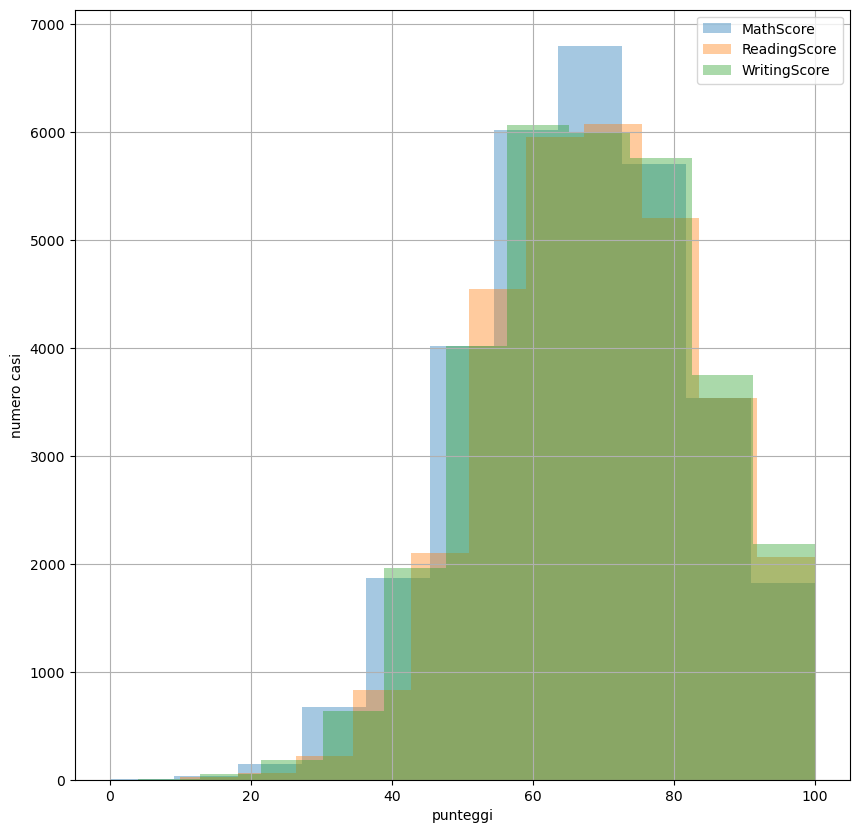

In [7]:
#Prendiamo le colonne che ci interessano
arrayMate = data['MathScore'].to_numpy()
arrayReading = data['ReadingScore'].to_numpy()
arrayWriting = data['WritingScore'].to_numpy()

listaGrafici = [arrayMate, arrayReading, arrayWriting]
nomi_colonne = ['MathScore', 'ReadingScore', 'WritingScore']

fig, ax = plt.subplots(figsize=(10, 10))
for array in listaGrafici:
    ax.hist(array, bins = 11, alpha = 0.4)
    ax.set_xlabel('punteggi')
    ax.set_ylabel('numero casi')
    ax.grid()
ax.legend(nomi_colonne)
    
plt.show()

### 3. Di matematica sono più brave le femmine o i maschi in media?

## Sono più bravi i maschi in media

come anche dimostrato con le query sottostanti i maschi hanno una media maggiore di quella delle femmine per quanto riguarda i test di matematica

In [31]:
data[data['Gender'] == 'female']['MathScore'].mean()

64.08065352697095

In [32]:
data[data['Gender'] == 'male']['MathScore'].mean()

69.06985608201354

In [13]:
data[['Gender', 'MathScore']].groupby("Gender").mean()

,MathScore
Gender,
female,64.080654
male,69.069856


### 4. Calcola il punteggio medio di matematica per tutti gli studenti, suddivisi a seconda di quanto sport praticano

In [33]:
data.groupby('PracticeSport')['MathScore'].mean()

PracticeSport
never        64.171079
regularly    67.839155
sometimes    66.274831
Name: MathScore, dtype: float64

In [16]:
data[['PracticeSport', 'MathScore']].groupby("PracticeSport").mean('MathScore')
#Ci sono medie più interessanti da poter fare, come la media armonica che leva le code di una normale
#i valori estremi

,MathScore
PracticeSport,
never,64.171079
regularly,67.839155
sometimes,66.274831


### 5. Aggiungi una nuova colonna al dataset nella quale inserisci la media tra il punteggio di scrittura e quello di lettura per ciascuno studente. Traccia un grafico utile a rilevare se questo nuovo punteggio medio è correlato al punteggio di matematica.

## In effetti è presente una correlazione tra questi punteggi

Infatti si può notare dal grafico scatter che più è alto il punteggio di matematica più la media dei punteggi di scrittura e lettura è alta

In [35]:
data['mediaScritturaLettura'] = (data['ReadingScore'] + data['WritingScore']) / 2
data.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore,mediaScritturaLettura
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74,72.5
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88,89.0
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91,92.0
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42,49.0
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75,76.5


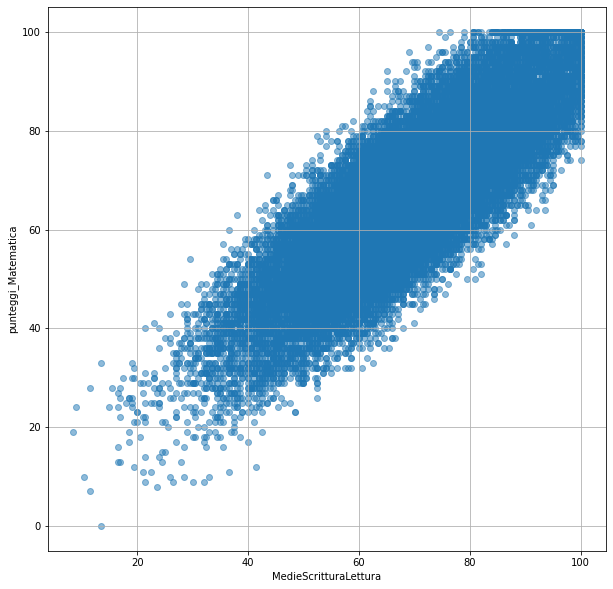

In [42]:
arrayMediaScritturaLettura = data['mediaScritturaLettura'].to_numpy()
arrayMate = data['MathScore'].to_numpy()

fig, ax = plt.subplots(figsize = (10,10))
ax.scatter(arrayMediaScritturaLettura, arrayMate, alpha = 0.5)
#ax.hist(arrayMediaScritturaLettura, bins = 11)
#ax.hist(arrayMate, bins = 11, alpha = 0.5)
ax.set_xlabel('MedieScritturaLettura')
ax.set_ylabel('punteggi_Matematica')
ax.grid()
plt.show()

### 6. [BONUS, facoltativo DSA] Calcola il punteggio medio di lettura, scrittura, matematica per tutti gli studenti raggruppati per livello di istruzione dei genitori. Infine salva questo DataFrame su un file .csv.

In [44]:
#dati_modificati = data['ParentEduc'].dropna() mean taglia i Nan
dati_modificati = data.groupby('ParentEduc')[['MathScore', 'ReadingScore', 'WritingScore']].mean()
dati_modificati

,MathScore,ReadingScore,WritingScore
ParentEduc,,,
associate's degree,68.365586,71.124324,70.299099
bachelor's degree,70.466627,73.062020,73.331069
high school,64.435731,67.213997,65.421136
master's degree,72.336134,75.832921,76.356896
some college,66.390472,69.179708,68.501432
some high school,62.584013,65.510785,63.632409


In [ ]:
dati_modificati.to_csv("media.csv")

In [18]:
data.groupby('ParentEduc')['ReadingScore'].mean()

ParentEduc
associate's degree    71.124324
bachelor's degree     73.062020
high school           67.213997
master's degree       75.832921
some college          69.179708
some high school      65.510785
Name: ReadingScore, dtype: float64

In [19]:
data.groupby('ParentEduc')['WritingScore'].mean()

ParentEduc
associate's degree    70.299099
bachelor's degree     73.331069
high school           65.421136
master's degree       76.356896
some college          68.501432
some high school      63.632409
Name: WritingScore, dtype: float64

In [38]:
#Correzione stile Tosello
data['value'] = data['ParentEduc'].notna()
media = data.groupby('ParentEduc')[['MathScore', 'ReadingScore', 'WritingScore']].mean()

In [43]:
media.dropna()

,MathScore,ReadingScore,WritingScore
ParentEduc,,,
associate's degree,68.365586,71.124324,70.299099
bachelor's degree,70.466627,73.062020,73.331069
high school,64.435731,67.213997,65.421136
master's degree,72.336134,75.832921,76.356896
some college,66.390472,69.179708,68.501432
some high school,62.584013,65.510785,63.632409
